# Phase 5 — Undervalued Property Detection

Flags listings where the XGBoost-predicted price exceeds the actual listing price by ≥ 20 %, then analyses which states and growth stages have the highest concentration of undervalued listings.

**Outputs**
- `data/processed/undervalued_properties.csv`
- `outputs/figures/05_value_gap_distribution.png`
- `outputs/figures/05_undervalued_by_cluster.png`
- `outputs/figures/05_undervalued_by_state.png`

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.utils import MODEL_PREDICTIONS, PROCESSED, FIGURES_DIR, ensure_dirs

ensure_dirs()

UNDERVALUED_THRESHOLD = 0.20

## 1. Load Predictions

In [2]:
df = pd.read_parquet(MODEL_PREDICTIONS)
print(f'Rows: {len(df):,}')
df[['price', 'predicted_price']].describe().round(0)

Rows: 702,438


,price,predicted_price
count,702438.0,702438.0
mean,564649.0,564899.0
std,719073.0,624846.0
min,10500.0,-248519.0
25%,239000.0,255288.0
50%,384000.0,399485.0
75%,619000.0,631442.0
max,9999999.0,9631747.0


## 2. Compute Value Gap

- `value_gap` = predicted − listed price  
- `value_gap_pct` = gap / listed price  
- `undervalued` = True when `value_gap_pct ≥ 20 %`

In [3]:
df['value_gap']     = df['predicted_price'] - df['price']
df['value_gap_pct'] = df['value_gap'] / df['price']
df['undervalued']   = df['value_gap_pct'] >= UNDERVALUED_THRESHOLD

n_undervalued = df['undervalued'].sum()
pct = n_undervalued / len(df) * 100
print(f'Undervalued properties (gap ≥ {UNDERVALUED_THRESHOLD*100:.0f}%): {n_undervalued:,}  ({pct:.1f}% of listings)')

Undervalued properties (gap ≥ 20%): 218,483  (31.1% of listings)


In [4]:
print('Value gap summary:')
df['value_gap_pct'].describe().apply(lambda x: f'{x:.3f}')

Value gap summary:


count    702438.000
mean          0.147
std           0.651
min          -3.957
25%          -0.125
50%           0.046
75%           0.268
max          79.968
Name: value_gap_pct, dtype: str

## 3. Distribution of Value Gap

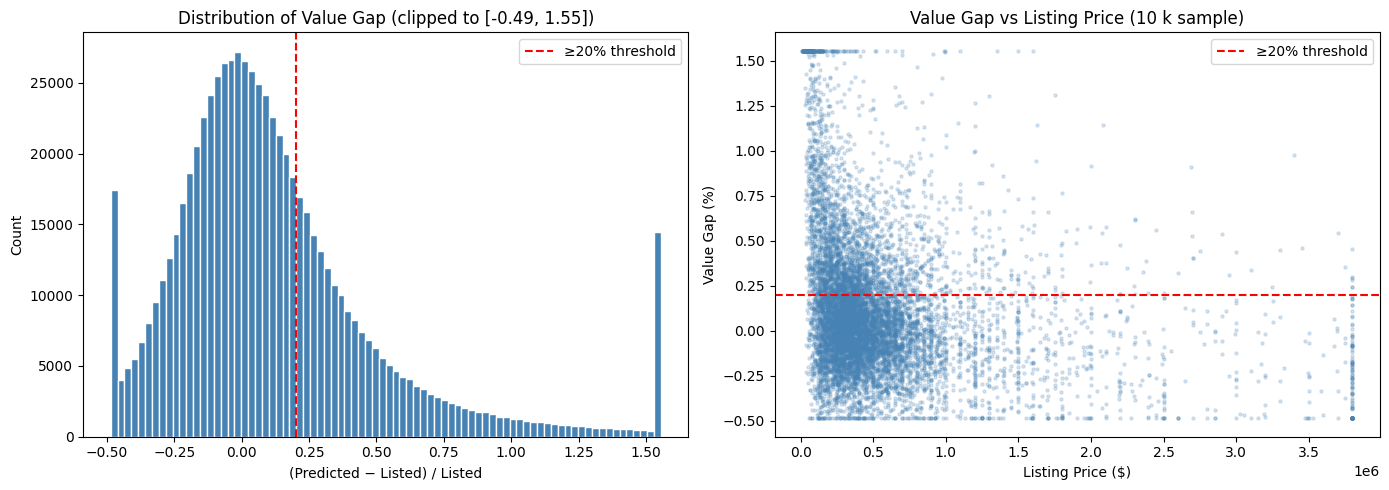

Saved → outputs/figures/05_value_gap_distribution.png


In [5]:
lo = df['value_gap_pct'].quantile(0.02)
hi = df['value_gap_pct'].quantile(0.98)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['value_gap_pct'].clip(lo, hi), bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(UNDERVALUED_THRESHOLD, color='red', linestyle='--',
                label=f'≥{UNDERVALUED_THRESHOLD*100:.0f}% threshold')
axes[0].set(
    title=f'Distribution of Value Gap (clipped to [{lo:.2f}, {hi:.2f}])',
    xlabel='(Predicted − Listed) / Listed',
    ylabel='Count'
)
axes[0].legend()

price_99 = df['price'].quantile(0.99)
sample_idx = df.sample(10_000, random_state=42).index
axes[1].scatter(
    df.loc[sample_idx, 'price'].clip(upper=price_99),
    df.loc[sample_idx, 'value_gap_pct'].clip(lo, hi),
    alpha=0.2, s=5, color='steelblue'
)
axes[1].axhline(UNDERVALUED_THRESHOLD, color='red', linestyle='--',
                label=f'≥{UNDERVALUED_THRESHOLD*100:.0f}% threshold')
axes[1].set(
    title='Value Gap vs Listing Price (10 k sample)',
    xlabel='Listing Price ($)',
    ylabel='Value Gap (%)'
)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_value_gap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/figures/05_value_gap_distribution.png')

## 4. Undervalued Rate by Growth Stage

Undervalued rate by growth stage:


,Fairly Valued (%),Undervalued (%)
cluster_label,,
Declining,65.1,34.9
Emerging,70.2,29.8
Gentrifying,68.1,31.9
Stable,65.7,34.3


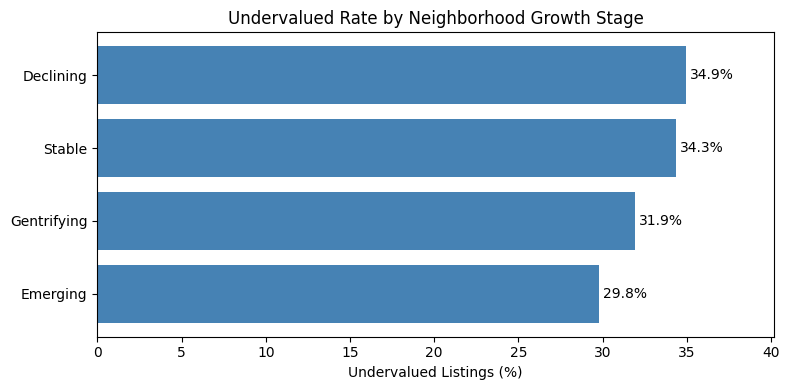

Saved → outputs/figures/05_undervalued_by_cluster.png


In [6]:
if 'cluster_label' in df.columns:
    cross = pd.crosstab(df['cluster_label'], df['undervalued'], normalize='index') * 100
    cross.columns = ['Fairly Valued (%)', 'Undervalued (%)']
    print('Undervalued rate by growth stage:')
    display(cross.round(1))

    sorted_vals = cross['Undervalued (%)'].sort_values()
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(sorted_vals.index, sorted_vals.values, color='steelblue')
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
    ax.set(
        xlabel='Undervalued Listings (%)',
        title='Undervalued Rate by Neighborhood Growth Stage',
        xlim=(0, sorted_vals.max() * 1.15)
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '05_undervalued_by_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → outputs/figures/05_undervalued_by_cluster.png')

## 5. Undervalued Rate by State

Top 10 states by undervalued rate:


,undervalued_rate,avg_gap,count
state_str,,,
Georgia,48.1,70810.703125,27201
Wyoming,48.0,39053.949219,1590
North Dakota,40.9,15937.138672,2146
West Virginia,40.9,23771.109375,3992
Mississippi,40.3,19061.580078,6064
Louisiana,40.1,18951.484375,11947
Minnesota,40.0,32568.335938,16147
Alabama,39.5,17007.746094,9762
Virginia,38.8,68039.632812,18531


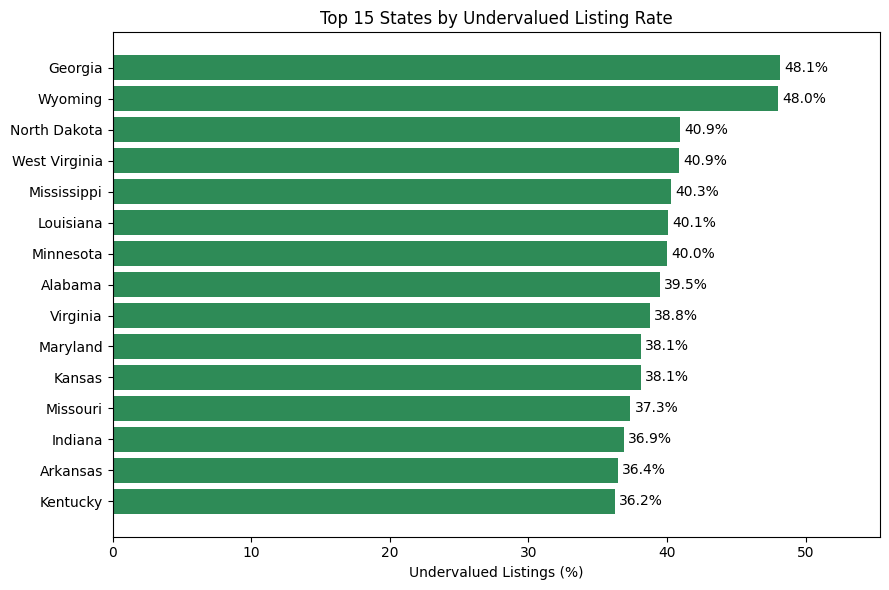

Saved → outputs/figures/05_undervalued_by_state.png


In [7]:
if 'state' in df.columns:
    state_stats = (
        df.assign(state_str=df['state'].astype(str))
        .groupby('state_str')
        .agg(
            undervalued_rate=('undervalued', 'mean'),
            avg_gap         =('value_gap',   'mean'),
            count           =('price',       'count'),
        )
        .query('count >= 50')
        .sort_values('undervalued_rate', ascending=False)
    )

    print('Top 10 states by undervalued rate:')
    top10 = state_stats.head(10).copy()
    top10['undervalued_rate'] = (top10['undervalued_rate'] * 100).round(1)
    display(top10[['undervalued_rate', 'avg_gap', 'count']])

    top15 = state_stats.head(15)
    sorted_states = (top15['undervalued_rate'] * 100).sort_values()

    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(sorted_states.index, sorted_states.values, color='seagreen')
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
    ax.set(
        xlabel='Undervalued Listings (%)',
        title='Top 15 States by Undervalued Listing Rate',
        xlim=(0, sorted_states.max() * 1.15)
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '05_undervalued_by_state.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → outputs/figures/05_undervalued_by_state.png')

## 6. Save Flagged Properties

In [8]:
cols = ['zip_code', 'state', 'city', 'price', 'predicted_price',
        'value_gap', 'value_gap_pct', 'undervalued',
        'bed', 'bath', 'house_size', 'cluster_label']
save_cols = [c for c in cols if c in df.columns]

out_path = PROCESSED / 'undervalued_properties.csv'
df[df['undervalued']][save_cols].sort_values('value_gap_pct', ascending=False).to_csv(out_path, index=False)
print(f'Saved {n_undervalued:,} undervalued properties → {out_path}')

Saved 218,483 undervalued properties → /Users/zacharypeng/projects/csen140proj/notebooks/../data/processed/undervalued_properties.csv


In [9]:
print('Top 10 most undervalued listings:')
df[df['undervalued']][save_cols].sort_values('value_gap_pct', ascending=False).head(10)

Top 10 most undervalued listings:


,zip_code,state,city,price,predicted_price,value_gap,value_gap_pct,undervalued,bed,bath,house_size,cluster_label
681000,97369,Oregon,Otter Rock,10600.0,8.582578e+05,8.476578e+05,79.967720,True,2.0,3.0,1669.0,Declining
541793,81620,Colorado,Beaver Creek,11000.0,8.169156e+05,8.059156e+05,73.265060,True,3.0,3.0,1800.0,Emerging
542071,81620,Colorado,Beaver Creek,12750.0,9.466318e+05,9.338818e+05,73.245636,True,3.0,3.0,1900.0,Emerging
680999,97369,Oregon,Otter Rock,10600.0,7.561201e+05,7.455201e+05,70.332085,True,2.0,2.0,1662.0,Declining
542108,81620,Colorado,Beaver Creek,14000.0,8.771217e+05,8.631217e+05,61.651550,True,3.0,3.0,1875.0,Emerging
561663,84098,Utah,Park City,12000.0,7.488019e+05,7.368019e+05,61.400158,True,2.0,2.0,1000.0,Stable
22578,12303,New York,Schenectady,20000.0,1.161171e+06,1.141171e+06,57.058552,True,4.0,3.0,2208.0,Gentrifying
457808,76384,Texas,Vernon,22000.0,1.055778e+06,1.033778e+06,46.989899,True,1.0,1.0,336.0,Declining
542105,81620,Colorado,Beaver Creek,17500.0,8.169156e+05,7.994156e+05,45.680893,True,3.0,3.0,1800.0,Emerging
541343,81620,Colorado,Beaver Creek,13900.0,6.326964e+05,6.187964e+05,44.517723,True,2.0,3.0,1300.0,Emerging
